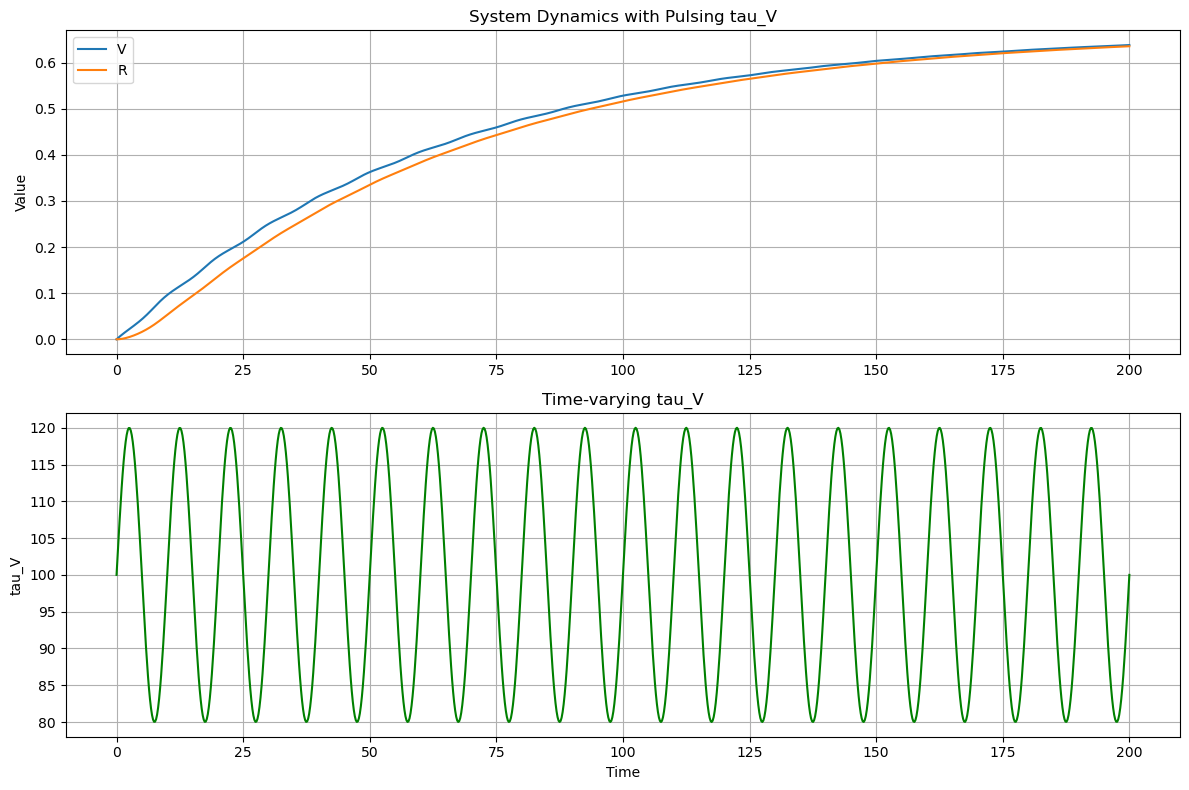

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def model(variables, t, params):
    V, R = variables
    # Unpack parameters (including pulse parameters)
    tau_V0, tau_R, n, k, pulse_amplitude, pulse_frequency, pulse_phase = params
    
    # Calculate time-dependent tau_V with pulsing
    tau_V = tau_V0 + pulse_amplitude * np.sin(2 * np.pi * pulse_frequency * t + pulse_phase)
    
    # ODEs
    dVdt = (1 - V - k * R) / tau_V
    dRdt = (V - R) / tau_R
    return [dVdt, dRdt]

# Parameters
tau_V0 = 100        # Baseline time constant for V
tau_R = 5           # Time constant for R
n = 1               # Hill coefficient
k = 0.5             # Feedback strength
pulse_amplitude = 20  # Amplitude of tau_V pulse
pulse_frequency = 0.1 # Pulse frequency (Hz)
pulse_phase = 0       # Phase offset

params = [tau_V0, tau_R, n, k, pulse_amplitude, pulse_frequency, pulse_phase]

# Initial conditions
V0 = 0
R0 = 0
initial_conditions = [V0, R0]

# Time points
t = np.linspace(0, 200, 1000)

# Solve ODE
solution = odeint(model, initial_conditions, t, args=(params,))
V, R = solution.T

# Calculate tau_V over time for plotting
tau_V_values = tau_V0 + pulse_amplitude * np.sin(2 * np.pi * pulse_frequency * t + pulse_phase)

# Plot results
plt.figure(figsize=(12, 8))

# Plot V and R
plt.subplot(2, 1, 1)
plt.plot(t, V, label='V')
plt.plot(t, R, label='R')
plt.ylabel('Value')
plt.title('System Dynamics with Pulsing tau_V')
plt.legend()
plt.grid(True)

# Plot tau_V
plt.subplot(2, 1, 2)
plt.plot(t, tau_V_values, label='tau_V(t)', color='green')
plt.xlabel('Time')
plt.ylabel('tau_V')
plt.title('Time-varying tau_V')
plt.grid(True)

plt.tight_layout()
plt.show()

### Key changes from the original:
### tau_V is now time-dependent with sinusoidal pulsing
### Added pulse parameters (amplitude, frequency, phase)
### Added calculation of tau_V_values for visualization
### Added a second subplot to show the time-varying tau_V
### I am reallyn